In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [22]:
df = pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [36]:
#df.head()
#print(df.shape)

In [34]:
df.info()

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [27]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [28]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [39]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [57]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0


In [63]:
X = df.drop(columns=['Exited']) 
Y = df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=1)

In [64]:
X_train.shape

(8000, 11)

In [65]:
Y_test.shape

(2000,)

In [67]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [68]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [121]:
# model = Sequential()
# model.add(Dense(15,activation='relu',input_dim = 11))
# model.add(Dense(15,activation='relu'))
# model.add(Dense(1,activation='sigmoid'))
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# First hidden layer
model.add(Dense(15, activation='relu', input_dim=11))
model.add(Dropout(0.3))

# Second hidden layer
model.add(Dense(15, activation='relu'))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [122]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 15)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 15)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 436 (1.70 KB)

 Trainable params: 436 (1.70 KB)

 Non-trainable params: 0 (0.00 B)

In [133]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics =['accuracy'])

In [137]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping( monitor='val_loss',patience=10, restore_best_weights=True)

In [138]:
history = model.fit(X_train_scaled,Y_train,epochs=200, validation_split=0.25,callbacks=[early_stop])

Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8347 - loss: 0.3920 - val_accuracy: 0.8545 - val_loss: 0.3501
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8376 - loss: 0.3811 - val_accuracy: 0.8565 - val_loss: 0.3475
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8326 - loss: 0.3842 - val_accuracy: 0.8560 - val_loss: 0.3488
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8414 - loss: 0.3721 - val_accuracy: 0.8575 - val_loss: 0.3494
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8454 - loss: 0.3750 - val_accuracy: 0.8590 - val_loss: 0.3481
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8346 - loss: 0.3866 - val_accuracy: 0.8580 - val_loss: 0.3468
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8374 - loss: 0.3950 - val_accuracy: 0.8605 - val_loss: 0.3468
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8447 - loss: 0.3738 - val_accu

In [139]:
model.layers[0].get_weights() #bias and weights

[array([[ 1.08852200e-01,  4.43368033e-03,  9.60448906e-02,
          8.66366476e-02,  2.79940248e-01,  2.40788870e-02,
          4.46023010e-02, -2.71340907e-02,  8.98288563e-02,
         -2.62154900e-02, -5.51896263e-03,  2.67970152e-02,
          7.08283335e-02, -1.33320644e-01, -4.02761772e-02],
        [ 2.87820488e-01,  2.95191497e-01, -7.95896649e-01,
         -6.63771868e-01, -2.49765754e-01,  3.44434306e-02,
          3.20087492e-01,  4.01301920e-01, -6.02096617e-01,
          9.59633142e-02,  1.16824679e-01,  2.81246584e-02,
         -6.73399627e-01, -6.12467647e-01, -4.55592602e-01],
        [ 3.76692191e-02,  1.98405296e-01, -4.81728166e-02,
         -2.07591038e-02, -2.30665907e-01, -4.46201814e-03,
         -2.10959576e-02, -2.89879609e-02,  1.31532056e-02,
          5.94686046e-02, -1.32872844e-02, -4.20878083e-02,
         -4.30584215e-02,  3.10397744e-02,  5.68422228e-02],
        [-1.02337152e-01, -1.24670014e-01, -4.41126467e-05,
         -1.46777481e-01,  7.26746693

In [140]:
model.predict(X_test_scaled) #we using sigmoid function whose values ranges between 0-1, so output is in between 0-1, 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.04471923],
       [0.08116557],
       [0.07140796],
       ...,
       [0.02155519],
       [0.05556818],
       [0.27545217]], dtype=float32)

In [141]:
#to convert the values in 0 and 1 we decide somw threshold value like thres_value is  less than 0.5 than it is 0 and if more than 0.5 then it is 1
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [142]:
np.where(y_log>0.5,1,0)

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [143]:
y_pred=np.where(y_log>0.5,1,0)

In [144]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.855

In [145]:
import matplotlib.pyplot as plt

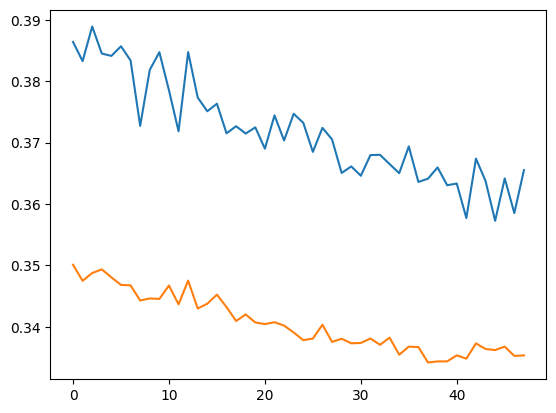

In [146]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

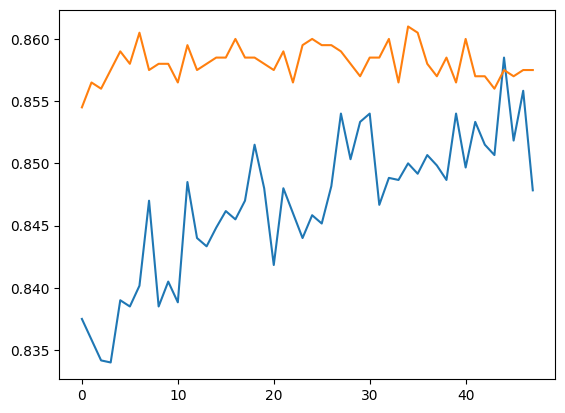

In [147]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])